## In-class hands-on activity: Regression Parts 1-2

### Real estate price prediction
主題: 建構迴歸模型、計算預測準確度、與處理類別型特徵。

走過下面的的Cell, 依序執行。下面有些Cell中標明"TODO"。請依照說明完成這些函數，讓整個檔案能正確的執行。

課程名稱: 統計學習與深度學習。授課教師: 盧信銘。任務設計: 盧信銘。

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import random
from sklearn.preprocessing import OneHotEncoder
from matplotlib import pyplot as plt
%matplotlib inline
plt.rcParams['font.family']=['Arial Unicode MS']
pd.set_option('display.max_column', 500)
pd.set_option('display.max_rows', 5000)
random.seed(1001)

### 資料說明

* 包含新北市, 台北市, 高雄市, 桃園市, 台中市房價資料
* 單價: 新台幣/坪，經過線性轉換，只有相對大小有意義。
* 建物面積、車位面積、陽台面積、附屬建物面積經過線性轉換，只有相對大小有意義。
* 橫坐標、縱坐標經過平移處理。

注意: 原資料提供者為避免法律爭議而進行資料轉換。這件事在一般統計學習與機器學習專案中需審慎為之。務必了解資料轉換對專案目標的影響。

In [2]:
# training data
dftrain = pd.read_csv('./housing_5cities_train.csv')
# test data
dftesta = pd.read_csv('./housing_5cities_testa.csv')
print(f"Training df shape = {dftrain.shape}; test df shape = {dftesta.shape}")

Training df shape = (8140, 21); test df shape = (1031, 21)


In [3]:
dftrain

,縣市,鄉鎮市區,路名,土地面積,使用分區,移轉層次,總樓層數,主要用途,主要建材,建物型態,屋齡,建物面積,車位面積,車位個數,橫坐標,縱坐標,備註,主建物面積,陽台面積,附屬建物面積,單價
0,台北市,大安區,敦化南路二段,-0.256716,NaN,11,11,住家用,鋼筋混凝土造,住宅大樓(11層含以上有電梯),32.583333,-0.174154,-0.819326,0.0,305266,2768378,NaN,0.393926,0.183700,-0.438452,4.627714
1,高雄市,鳳山區,北忠街,0.181921,NaN,10,15,集合住宅,其他,住宅大樓(11層含以上有電梯),6.166667,0.423366,0.161624,1.0,184815,2504666,NaN,-0.098871,-0.360620,1.525881,1.489072
2,新北市,新莊區,福前街,0.085594,NaN,9,14,集合住宅,鋼筋混凝土造,住宅大樓(11層含以上有電梯),8.833333,0.164249,0.524653,1.0,296653,2772355,NaN,-0.071147,0.315088,0.231984,2.051217
3,台北市,萬華區,國興路,0.260510,NaN,2,12,住家用,鋼筋混凝土造,住宅大樓(11層含以上有電梯),39.333333,-0.411438,-0.819326,0.0,301365,2768583,NaN,-0.371295,-0.618277,-0.438452,2.238599
4,新北市,樹林區,信義街,0.856422,NaN,2,4,住家用,鋼筋混凝土造,公寓(5樓含以下無電梯),46.000000,-0.868770,-0.819326,0.0,292687,2763850,NaN,-0.245408,-1.642077,-0.438452,1.348536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8135,台北市,內湖區,陽光街,0.544299,NaN,5,5,住家用,鋼筋混凝土造,公寓(5樓含以下無電梯),39.166667,-0.378115,-0.819326,0.0,309040,2774177,NaN,0.241730,0.233184,-0.438452,2.660207
8136,新北市,新莊區,幸福東路,1.390665,NaN,3,25,集合住宅,鋼骨造,住宅大樓(11層含以上有電梯),1.166667,2.090101,3.220335,2.0,296674,2771379,NaN,1.548971,0.516435,1.143690,2.613362
8137,桃園市,八德區,介壽路二段,0.706189,其他,4,5,住家用,鋼筋混凝土造,公寓(5樓含以下無電梯),28.333333,-0.271825,0.484488,1.0,280165,2758675,NaN,0.146962,-0.181455,-0.171559,0.903505
8138,新北市,土城區,學士路,-1.147111,NaN,12,16,住家用,鋼筋混凝土造,住宅大樓(11層含以上有電梯),25.083333,-1.199130,-0.819326,0.0,295794,2763966,NaN,-1.333408,-0.708713,-0.438452,2.285444


In [4]:
# Summary statistics
dftrain.describe()

,土地面積,移轉層次,總樓層數,屋齡,建物面積,車位面積,車位個數,橫坐標,縱坐標,主建物面積,陽台面積,附屬建物面積,單價
count,8140.000000,8140.000000,8140.000000,8140.000000,8140.000000,8140.000000,8140.000000,8140.000000,8.140000e+03,8140.000000,8140.000000,8140.000000,8140.000000
mean,-0.000685,7.431818,12.571376,22.164281,0.018220,0.001344,0.617199,273558.099017,2.725461e+06,0.026784,0.026401,0.032724,2.087195
std,1.087028,5.097901,6.906708,14.623925,1.090130,1.034322,0.679794,44740.087322,8.998772e+04,1.089884,1.082033,1.243377,1.008621
min,-1.613242,2.000000,2.000000,0.000000,-1.788606,-0.819326,0.000000,175366.000000,2.495675e+06,-2.070340,-1.642077,-0.438452,0.177415
25%,-0.658185,4.000000,7.000000,8.833333,-0.635508,-0.819326,0.000000,272150.000000,2.758728e+06,-0.622573,-0.637473,-0.438452,1.395381
50%,-0.171048,6.000000,12.000000,22.500000,-0.216670,-0.538172,1.000000,295689.000000,2.767386e+06,-0.149791,-0.070544,-0.438452,1.816990
75%,0.384950,10.000000,15.000000,33.500000,0.332158,0.674885,1.000000,302298.750000,2.772287e+06,0.404393,0.474203,0.144443,2.519671
max,19.475175,46.000000,68.000000,60.083333,9.181627,9.221895,3.000000,326906.000000,2.790801e+06,10.800366,13.842902,33.713188,11.326608


可以很明確地看到土地面積、建物面積、車位面積、主建物面積、陽台面積、單價有被標準化的痕跡。

---

Exploratory Data Analysis (EDA)不是這個練習的重點，因此選擇性的畫個圖看一下。

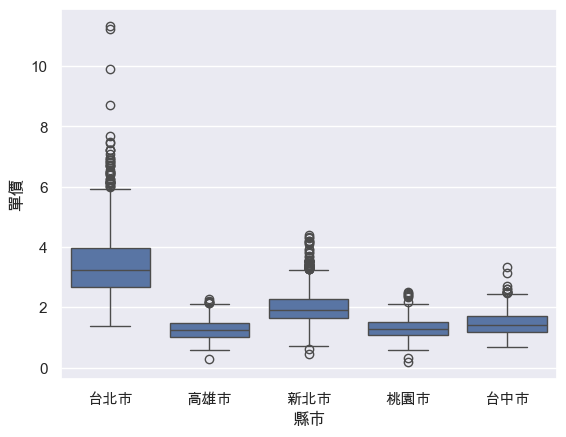

In [30]:
# 確保中文能正常顯示
sns.set(font="SimSun")
plt.rcParams['font.family']=['Arial Unicode MS']
sns.boxplot(dftrain, x = "縣市", y = "單價")
plt.show()

### Fit a linear model;
Recall that the closed form solution for linear regression coefficient is:

$\hat{\beta} = (X^T X)^{-1} X^T y$

You may need to leverage the following methods:
* df.to_numpy
* numpy.linalg.inv or numpy.linalg.solve
* numpy.matmul or @
* numpy.ones
* numpy.hstack


In [6]:
# TODO
def fit_linear_reg(X_train:np, y_train:np):
    # implement the closed form solution for linear regression
    # return the fitted coefficients
    # remember to add a column of ones first

    # # ---- remove below ---
    # c0 = np.ones((X_train.shape[0], 1))
    # X_train = np.hstack((c0, X_train))    
    # beta_head = np.linalg.inv(np.transpose(X_train) @ X_train) @ np.transpose(X_train) @ y_train
    # return beta_head
    # # ---- remove above ---
    col1 = np.ones((X_train.shape[0], 1))
    X_train=np.hstack((col1,X_train))
    beta_head=np.linalg.inv(np.transpose(X_train)@X_train)@np.transpose(X_train)@y_train
    return beta_head
    # return np.zeros((X_train.shape[1]))

In [7]:
numfeatures = ['建物面積', '總樓層數', '屋齡']
label = '單價'
X_train = dftrain[numfeatures].to_numpy()
y_train = dftrain[label].to_numpy()
X_test = dftesta[numfeatures].to_numpy()
y_test = dftesta[label].to_numpy()

beta_head = fit_linear_reg(X_train, y_train)

for abeta, aname in zip(beta_head, ['Const.'] + numfeatures):
    print(f"{aname}\t{abeta:.4f}")

Const.	1.8937
建物面積	0.0454
總樓層數	0.0042
屋齡	0.0063


### Sanity Check
The cell output should be like:
<pre>
Const.	1.8937
建物面積	0.0454
總樓層數	0.0042
屋齡	0.0063
</pre>

### Compute $R^2$

In [8]:
# TODO
def get_r2(X:np, y:np, beta):
    # Compute R2 given X, y, and beta
    # return R2 as a scalar

    # --- remove below ---
    # y_mean = np.mean(y)
    # SST = np.sum((y - y_mean) ** 2)
    # # compute SSE
    # c0 = np.ones((X.shape[0], 1))
    # X = np.hstack((c0, X))  
    # yhead = X @ beta
    # error = yhead - y
    # SSE = np.sum(error ** 2)
    
    # return 1 - SSE / SST
    # --- remove above ---
    y_mean= np.mean(y)
    sst=np.sum((y-y_mean)**2)
    col0 =np.ones((X.shape[0],1))
    X = np.hstack((col0, X))  
    yhead = X@beta
    error =yhead -y
    sse =np.sum(error **2)
    Rsquare= 1-sse/sst
    return Rsquare
    # return 0.0

In [9]:
r2 = get_r2(X_train, y_train, beta_head)
print(f"R2 = {r2:.4f}")

R2 = 0.0071


## Sanity Check
The above cell should have an output like this:
<pre>
R2 = 0.0071
</pre>

### Extend get_r2 to also compute RMSE, MAE, MAPE

In [10]:
# TODO
def get_performance(X:np, y:np, beta):
    # Compute R2, RMSE, MAE, MAPE given X, y, and beta
    # return R2, RMSE, MAE, MAPE as a list
    
    # --- remove below ---
    # y_mean = np.mean(y)
    # SST = np.sum((y - y_mean) ** 2)
    # # compute SSE
    # c0 = np.ones((X.shape[0], 1))
    # X = np.hstack((c0, X))  
    # yhead = X @ beta
    # error = yhead - y
    # SSE = np.sum(error ** 2)
    # MAE = np.mean(abs(error))
    # RMSE = (np.mean(error ** 2)) ** 0.5
    # MAPE = np.mean(abs(error / y))
    
    # return 1 - SSE / SST, RMSE, MAE, MAPE
    # --- remove above ---
    y_mean =np.mean(y)
    sst =np.sum((y-y_mean)**2)
    col0=np.ones((X.shape[0],1))
    X =np.hstack((col0,X))
    y_head=X@beta
    error = y_head-y
    sse = np.sum(error**2)
    mae =np.mean(abs(error))
    rmse =(np.mean(error**2))**0.5
    mape =np.mean(abs(error/y))
    return 1- sse/sst ,rmse,mae,mape

    # return 0.0, 0.0, 0.0, 0.0

In [11]:
# performance on training data
r2, RMSE, MAE, MAPE = get_performance(X_train, y_train, beta_head)
print(f"R2 = {r2:.4f}")
print(f"RMSE = {RMSE:.4f}")
print(f"MAE = {MAE:.4f}")
print(f"MAPE = {MAPE:.4f}")

R2 = 0.0071
RMSE = 1.0050
MAE = 0.7498
MAPE = 0.4166


### Sanity Check
The above cell should have an output like this:
<pre>
R2 = 0.0071
RMSE = 1.0050
MAE = 0.7498
MAPE = 0.4166
</pre>

In [12]:
# performance on test data
r2, RMSE, MAE, MAPE = get_performance(X_test, y_test, beta_head)
print(f"R2 = {r2:.4f}")
print(f"RMSE = {RMSE:.4f}")
print(f"MAE = {MAE:.4f}")
print(f"MAPE = {MAPE:.4f}")

R2 = 0.0173
RMSE = 1.0382
MAE = 0.7238
MAPE = 0.3965


### Sanity Check
The above cell should have an output like this:
<pre>
R2 = 0.0173
RMSE = 1.0382
MAE = 0.7238
MAPE = 0.3965
</pre>

### Deal with categorical features

In [13]:
# TODO
def gen_features(dftrain:pd.DataFrame, dftest:pd.DataFrame, numfeatures, catfeatures, enc:OneHotEncoder):
    # Generate additional categorical features according to catfeatures
    # use enc to help you generate feature one-hot encoding. 
    # np.hstack will be useful here. 
    # Arrange numpy array such that numerical features go first, followed by categorical features
    # return the feature arrary for training and test data

    # --- remove below ---
    # X_train = dftrain[numfeatures].to_numpy()    
    # enc.fit(dftrain[catfeatures])
    # X_train_cat = enc.transform(dftrain[catfeatures]).toarray()
    # X_train2 = np.hstack((X_train, X_train_cat))

    # X_test = dftesta[numfeatures].to_numpy()
    # X_test_cat = enc.transform(dftesta[catfeatures]).toarray()
    # X_test2 = np.hstack((X_test, X_test_cat))

    # return X_train2, X_test2
    # # --- remove above ---
    X_train=dftrain[numfeatures].to_numpy()
    enc.fit(dftrain[catfeatures])

    X_train_cat =enc.transform(dftrain[catfeatures]).toarray()
    X_train2=np.hstack((X_train,X_train_cat))
    
    X_test=dftesta[numfeatures].to_numpy()
    X_test_cat =enc.transform(dftesta[catfeatures]).toarray()
    X_test2= np.hstack((X_test, X_test_cat))  
    return X_train2 ,X_test2
    # return np.zeros(dftrain.shape), np.zeros(dftest.shape)


In [14]:
numfeatures = ['建物面積', '總樓層數', '屋齡']
catfeatures = ['縣市']
label = '單價'

enc = OneHotEncoder(drop="first")
X_train2, X_test2 = gen_features(dftrain, dftesta, numfeatures, catfeatures, enc)
y_train2 = dftrain[label].to_numpy()
y_test2 = dftesta[label].to_numpy()

beta_head2 = fit_linear_reg(X_train2, y_train2)

featname = ['Const.'] + numfeatures + list(enc.categories_[0][1:])
for abeta, aname in zip(beta_head2, featname):
    print(f"{aname}\t{abeta:.4f}")

Const.	1.3455
建物面積	0.0095
總樓層數	0.0211
屋齡	-0.0123
台北市	2.2398
新北市	0.6374
桃園市	-0.1296
高雄市	-0.2285


### Sanity Check
The above cell should have an output like this:
<pre>
Const.	1.3455
建物面積	0.0095
總樓層數	0.0211
屋齡	-0.0123
台北市	2.2398
新北市	0.6374
桃園市	-0.1296
高雄市	-0.2285
</pre>

In [15]:
# Check training performance
r2, RMSE, MAE, MAPE = get_performance(X_train2, y_train2, beta_head2)
print(f"R2 = {r2:.4f}")
print(f"RMSE = {RMSE:.4f}")
print(f"MAE = {MAE:.4f}")
print(f"MAPE = {MAPE:.4f}")

R2 = 0.6715
RMSE = 0.5781
MAE = 0.3983
MAPE = 0.1964


### Sanity Check
The above cell should have an output like this:
<pre>
R2 = 0.6715
RMSE = 0.5781
MAE = 0.3983
MAPE = 0.1964
</pre>

In [16]:
# Check test performance
r2, RMSE, MAE, MAPE = get_performance(X_test2, y_test2, beta_head2)
print(f"R2 = {r2:.4f}")
print(f"RMSE = {RMSE:.4f}")
print(f"MAE = {MAE:.4f}")
print(f"MAPE = {MAPE:.4f}")

R2 = 0.5937
RMSE = 0.6676
MAE = 0.4050
MAPE = 0.1933


### Sanity Check
The above cell should have an output like this:
<pre>
R2 = 0.5937
RMSE = 0.6676
MAE = 0.4050
MAPE = 0.1933
</pre>


### Before closing out today's activity

Let's take a look at the locations in our training data.
How can we leverage the locations in our models?

After all, the most important factors in real estate is: <h3>Location, Location, Location.</h3>

<Axes: xlabel='橫坐標', ylabel='縱坐標'>

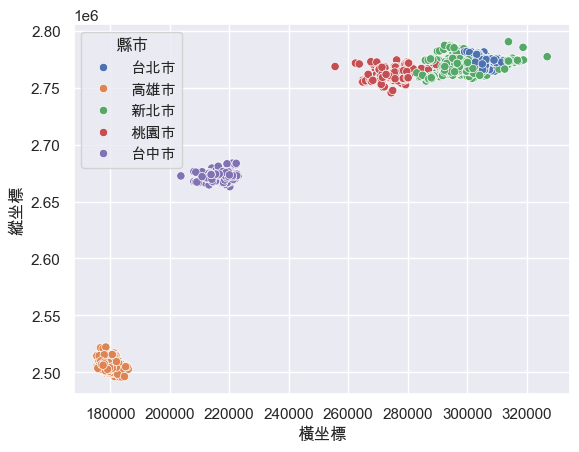

In [31]:
sns.scatterplot(dftrain, x="橫坐標", y="縱坐標", hue = "縣市")

In [18]:
dftrain_ks = dftrain[dftrain.縣市 == "高雄市"]

<Axes: xlabel='橫坐標', ylabel='縱坐標'>

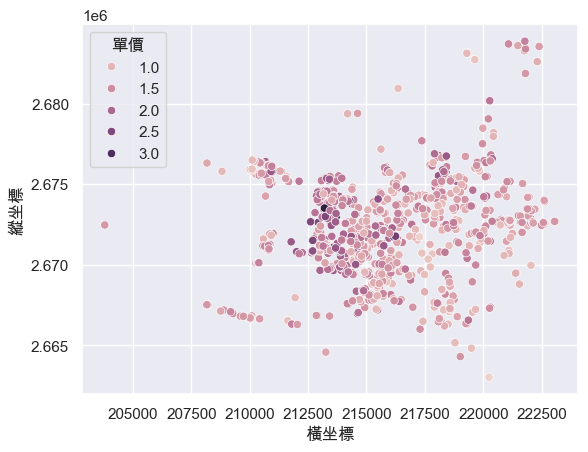

In [32]:
sns.scatterplot(dftrain_ks, x="橫坐標", y="縱坐標", hue = "單價")

---- 
End of File

---

In [20]:


# loop over all grids
# for each grid
#    identify grids in the points
#    compute the center of these points
#    computer the std along x and y axis
#    skip if too few points
#    record uj and sj, and data point count

mu_x_all = []
mu_y_all = []
std_x_all = []
std_y_all = []
count_all = []

ngrid = 3 # divide into ngrid by ngrid

cities = ['新北市', '台北市', '高雄市', '桃園市', '台中市']
for acity in cities:
    dftrain_ks = dftrain[dftrain.縣市 == acity]
    print(acity, dftrain_ks.shape)
    coord_x = dftrain_ks.橫坐標.values
    coord_y = dftrain_ks.縱坐標.values
    
    xmin = min(coord_x)
    xmax = max(coord_x) + 0.1 # a convenient slack to fix boundary issue
    ymin = min(coord_y)
    ymax = max(coord_y) + 0.1 # a convenient slack to fix boundary issue
    
    xgrids = np.linspace(xmin, xmax, ngrid+1)
    ygrids = np.linspace(ymin, ymax, ngrid+1)
    
    
    for i in range(ngrid):
        for j in range(ngrid):
            x1 = xgrids[i]
            x2 = xgrids[i+1]
            y1 = ygrids[j]
            y2 = ygrids[j+1]
            tmpindx = (x1 <= coord_x) * (coord_x < x2)
            tmpindy = (y1 <= coord_y) * (coord_y < y2)
            tmpind = tmpindx * tmpindy
            npoints = np.sum(tmpind)
            if npoints < 20:
                print(f" - Only {npoints} points in grid {i}, {j}, skip")
                continue
            mu_x = np.mean(coord_x[tmpind])
            mu_y = np.mean(coord_y[tmpind])
            std_x = np.std(coord_x[tmpind])
            std_y = np.std(coord_y[tmpind])
            print(f"grid {i}, {j} N={npoints}; \tMean=({mu_x:.4f}, {mu_y:.4f})\tStd=({std_x:.4f}, {std_y:.4f})")
            
            mu_x_all.append(mu_x)
            mu_y_all.append(mu_y)
            std_x_all.append(std_x)
            std_y_all.append(std_y)
            count_all.append(npoints)
        
        
        


新北市 (3432, 21)
grid 0, 0 N=713; 	Mean=(292369.0337, 2763437.3282)	Std=(4312.3875, 2775.6795)
grid 0, 1 N=1007; 	Mean=(293614.6643, 2772099.6127)	Std=(3412.0865, 2647.8435)
grid 0, 2 N=186; 	Mean=(295035.5430, 2784392.3763)	Std=(1318.5717, 2298.6343)
grid 1, 0 N=712; 	Mean=(301675.7921, 2764930.0772)	Std=(2192.9876, 1904.6775)
grid 1, 1 N=520; 	Mean=(299145.3827, 2772523.1442)	Std=(1407.3651, 2523.0376)
 - Only 3 points in grid 1, 2, skip
 - Only 13 points in grid 2, 0, skip
grid 2, 1 N=274; 	Mean=(315246.3832, 2773332.7701)	Std=(1667.1212, 1003.3351)
 - Only 4 points in grid 2, 2, skip
台北市 (1906, 21)
grid 0, 0 N=90; 	Mean=(300711.6667, 2768906.2667)	Std=(714.5537, 531.0706)
grid 0, 1 N=146; 	Mean=(301296.2397, 2772116.7192)	Std=(549.8669, 1735.3693)
grid 0, 2 N=122; 	Mean=(300588.1475, 2779867.8934)	Std=(1331.3471, 1608.3421)
grid 1, 0 N=430; 	Mean=(304968.3372, 2768095.4512)	Std=(1361.0391, 1561.2120)
grid 1, 1 N=565; 	Mean=(304675.4496, 2772124.5858)	Std=(1445.8699, 1476.4261)
grid 1

In [21]:
len(mu_x_all)

32

Compute Gaussian Basis Function; 

Recall for a data point x_a, and anchor mu_j with std s_j
the feature value is $exp(- \frac{(x_a - \mu_j)^2}{2 s_j^2})$

Now we are dealing with two-dimensional case. 
For data point x_a, y_a and anchor mu_xj, mu_yj std std s_xj, s_yj,


the feature values is $exp(- \frac{(x_a - \mu_{xj})^2}{2 s_{xj}^2} - \frac{(y_a - \mu_{yj})^2}{2 s_{yj}^2} )$



In [22]:
# add 31 new features
def gaussin_basis(coord_x, coord_y, mu_x_all, mu_y_all, std_x_all, std_y_all):
    ngf = len(mu_x_all)
    gf_all = np.zeros((coord_x.shape[0], ngf))
    
    for ii in range(ngf):
        mu_x = mu_x_all[ii]
        mu_y = mu_y_all[ii]
        std_x = std_x_all[ii]
        std_y = std_y_all[ii]
        
        # doing this in a vectorized way
        tmpgf = np.exp(-(coord_x - mu_x) ** 2 / (2 * std_x ** 2) - (coord_y - mu_y) ** 2 / (2 * std_y ** 2))
        gf_all[:,ii] = tmpgf
    
    return gf_all

coord_x = dftrain.橫坐標.values
coord_y = dftrain.縱坐標.values
gf_all_train = gaussin_basis(coord_x, coord_y, mu_x_all, mu_y_all, std_x_all, std_y_all)
gf_all_test = gaussin_basis(dftesta.橫坐標.values, dftesta.縱坐標.values, mu_x_all, mu_y_all, std_x_all, std_y_all)
y_train3 = y_train2

# add gaussian features
X_train3 = np.hstack((X_train2, gf_all_train))
X_test3 = np.hstack((X_test2, gf_all_test))
y_test3 = y_test2


In [23]:
beta_head3 = fit_linear_reg(X_train3, y_train3)
# print(beta_head2)
ngf = len(mu_x_all)
featname = ['Const.'] + numfeatures + list(enc.categories_[0][1:]) + ["gf" + str(a) for a in range(ngf)]
for abeta, aname in zip(beta_head3, featname):
    print(f"{aname}\t{abeta:.4f}")

Const.	1.4029
建物面積	0.0011
總樓層數	0.0164
屋齡	-0.0176
台北市	1.8396
新北市	0.6013
桃園市	-0.1316
高雄市	-0.2096
gf0	0.1426
gf1	0.1132
gf2	-0.8641
gf3	0.6836
gf4	0.4951
gf5	0.0259
gf6	-0.5456
gf7	-0.3103
gf8	-0.5668
gf9	1.8730
gf10	1.5239
gf11	0.5328
gf12	0.0624
gf13	0.5269
gf14	0.1478
gf15	0.3280
gf16	-0.1193
gf17	0.2737
gf18	0.0868
gf19	-0.2425
gf20	0.0052
gf21	0.0049
gf22	-0.6149
gf23	-0.0316
gf24	0.3929
gf25	-0.0284
gf26	0.0990
gf27	0.0302
gf28	0.4255
gf29	-0.1228
gf30	-0.0070
gf31	-0.0471


In [24]:
r2, RMSE, MAE, MAPE = get_performance(X_train3, y_train3, beta_head3)
print(f"R2 = {r2:.4f}")
print(f"RMSE = {RMSE:.4f}")
print(f"MAE = {MAE:.4f}")
print(f"MAPE = {MAPE:.4f}")

R2 = 0.7681
RMSE = 0.4856
MAE = 0.3276
MAPE = 0.1600


In [25]:
r2, RMSE, MAE, MAPE = get_performance(X_test3, y_test3, beta_head3)
print(f"R2 = {r2:.4f}")
print(f"RMSE = {RMSE:.4f}")
print(f"MAE = {MAE:.4f}")
print(f"MAPE = {MAPE:.4f}")

R2 = 0.6847
RMSE = 0.5881
MAE = 0.3326
MAPE = 0.1573
